# Men's Singles Figure Skating World Championship Scores Analysis (2005-2026)
## ACC102 Track2 Project

---

### Project Goal
This project analyzes the evolution of men's singles figure skating performance at the World Championships from 2005 to 2026. It examines how total scores, technical element scores (TES), and program component scores (PCS) have changed over time, and explores the impact of technical difficulty on competitive results.

---

### Target User
- Figure skating fans and enthusiasts who want to understand the sport’s scoring system and performance trends
- Aspiring skaters and coaches seeking data-driven insights into how technical vs. artistic elements contribute to success
- Sports media and analysts interested in the development of competitive figure skating standards

---

### Data Source & Information
This project combines two complementary sources of figure skating competition data:

1.  **Kaggle Dataset**
    - Dataset Name: *Men's Figure Skating World Championship Scores (2005-2024)*
    - Author: MITCHELL FRIESS
    - URL: https://www.kaggle.com/datasets/mitchellfriess/fsscores
    - Access Date: April 2026

2.  **ISU (International Skating Union) Official Website**
    - URL: https://www.isu.org
    - Access Date: April 2026
    - Usage: Official PDF protocol sheets for the 2025 and 2026 World Championships, used to supplement and verify data.

Combining these two sources ensures both comprehensive historical coverage (from Kaggle) and official validation (from the ISU).

---

### Key Variables
| Variable | Description |
|----------|-------------|
| `Year` | Competition year (2005-2026) |
| `Skater` | Athlete name |
| `SP Total` | Short program total score |
| `SP TES` | Short program technical element score |
| `SP PCS` | Short program program component score |
| `Quads in SP` | Number of quadruple jumps attempted in the short program |
| `FS Total` | Free skating total score |
| `FS TES` | Free skating technical element score |
| `FS PCS` | Free skating program component score |
| `Quads in FS` | Number of quadruple jumps attempted in the free skating |


# Step 1: Import Required Libraries
In this section, we import the necessary Python libraries for data processing, analysis, and visualization:

- `pandas`: Used for data manipulation and analysis, particularly for working with structured data (e.g., CSV files).
- `matplotlib.pyplot`: A plotting library for creating static, animated, and interactive visualizations in Python. We will use this for plotting graphs and charts.
- `numpy`: A library for numerical computing, offering support for large multi-dimensional arrays and matrices, along with a collection of mathematical functions to operate on these arrays.
- `seaborn`: Built on top of matplotlib, seaborn is a data visualization library that provides a high-level interface for drawing attractive and informative statistical graphics. It simplifies the creation of complex visualizations like heatmaps, line charts, and more.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Step 2: Load and Inspect the Dataset
We start by loading the dataset and performing basic checks to understand its structure and quality.

In [39]:
# Read the CSV file containing men's singles skating scores
df = pd.read_csv('WC Scores Men.csv') 

# Check for missing values in each column
print(df.isnull().sum())

# Preview the first few rows of data from the year 2026
print(df[df['Year'] == 2026].head())

Year           0
Skater         0
SP Total       0
SP TES         0
SP PC          0
Quads in SP    0
FS Total       0
FS TES         0
FS PC          0
Quads in FS    0
dtype: int64
     Year       Skater  SP Total  SP TES  SP PC  Quads in SP  FS Total  \
477  2026      Malinin    111.29   65.05  46.24            2    218.11   
478  2026     Kagiyama     93.80   49.07  45.73            2    212.87   
479  2026         Sato     95.84   52.66  43.18            2    192.70   
480  2026      Gogolev     94.38   53.90  40.48            2    186.66   
481  2026  Siao Him Fa    101.85   56.18  45.67            2    169.71   

     FS TES  FS PC  Quads in FS  
477  123.07  95.04            5  
478  116.30  96.57            3  
479  106.12  86.58            3  
480  103.40  83.26            3  
481   83.67  87.04            3  


# Step 3: Visualize Short Program (SP) Scores Trend
We use a scatter plot to visualize how short program total scores have changed over the years, to see the overall trend in competition difficulty and performance levels.

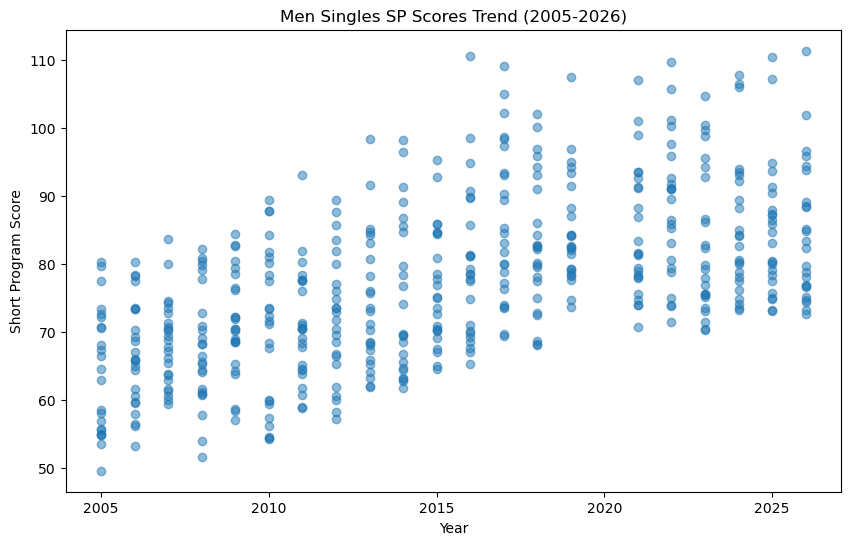

In [40]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a scatter plot: Year vs. Short Program Total Score
plt.scatter(df['Year'], df['SP Total'], alpha=0.5)

# Add title and axis labels
plt.title('Men Singles SP Scores Trend (2005-2026)')
plt.xlabel('Year')
plt.ylabel('Short Program Score')

# Display the plot
plt.show()

# Step 4: Visualize Free Skating (FS) Scores Trend with Trend Line
Next, we analyze the free skating scores trend, adding a linear trend line to highlight the overall upward direction of scores over time.

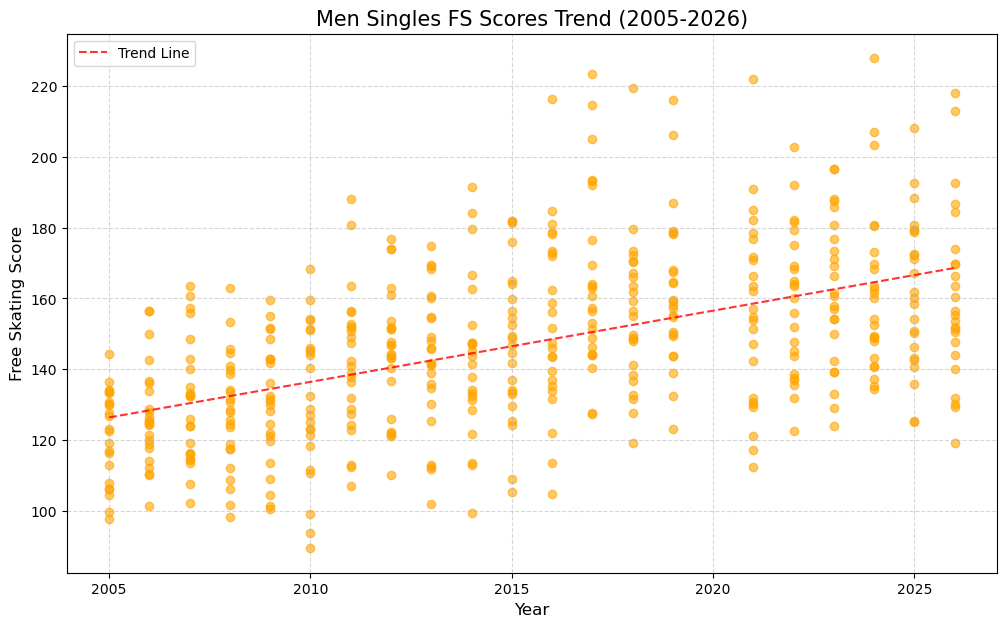

In [42]:
# Set the figure size
plt.figure(figsize=(12, 7))

# Create a scatter plot: Year vs. Free Skating Total Score (orange color)
plt.scatter(df['Year'], df['FS Total'], alpha=0.6, color='orange')

# Add title and axis labels
plt.title('Men Singles FS Scores Trend (2005-2026)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Free Skating Score', fontsize=12)

# Fit a linear trend line (1st-degree polynomial)
z = np.polyfit(df['Year'], df['FS Total'], 1) 
p = np.poly1d(z)

# Plot the trend line as a red dashed line
plt.plot(df['Year'], p(df['Year']), "r--", alpha=0.8, label='Trend Line') 

# Add legend and grid lines
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Display the plot
plt.show()

# Step 5: Evolution of Short Program Scores - TES vs. PCS
Here we compare the average Technical Element Score (TES) and Program Component Score (PCS) in the short program over the years, to see whether technical or artistic scores have grown faster.

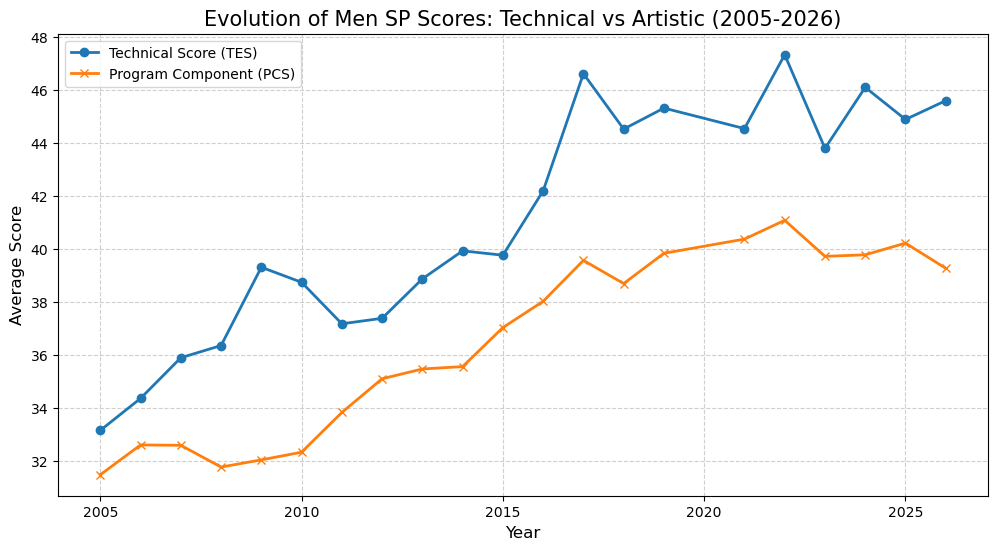

In [46]:
# Group data by year and calculate the average TES and PCS for the short program
yearly_avg = df.groupby('Year')[['SP TES', 'SP PC']].mean()

# Set the figure size
plt.figure(figsize=(12, 6))

# Plot the trend lines for TES and PCS
plt.plot(yearly_avg.index, yearly_avg['SP TES'], marker='o', label='Technical Score (TES)', linewidth=2)
plt.plot(yearly_avg.index, yearly_avg['SP PC'], marker='x', label='Program Component (PCS)', linewidth=2)

# Add title and axis labels
plt.title('Evolution of Men SP Scores: Technical vs Artistic (2005-2026)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Score', fontsize=12)

# Add legend and grid lines
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

# Step 6: Evolution of Free Skating Scores - TES vs. PCS
We repeat the same comparison for the free skating scores, to see the trend of technical and artistic scores in the longer program.

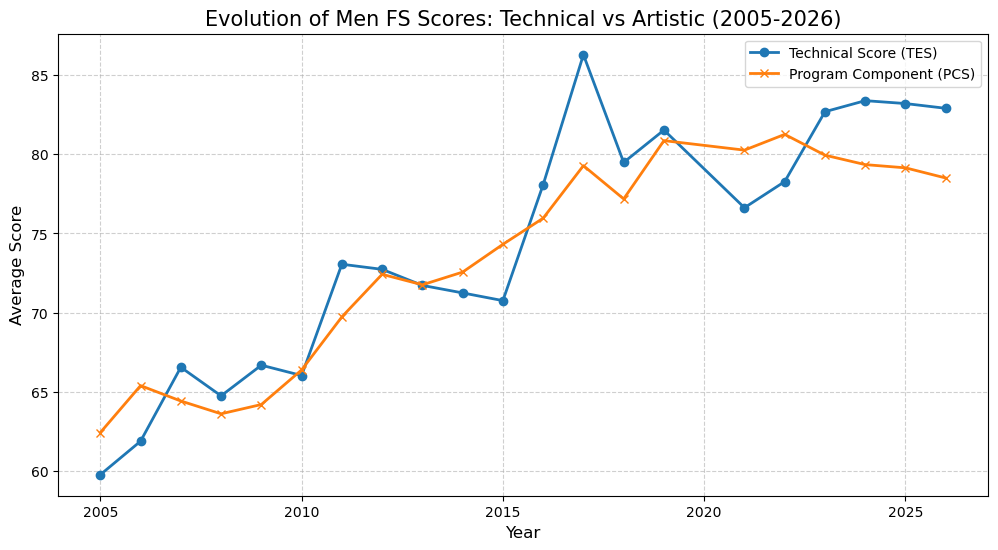

In [28]:
# Group data by year and calculate the average TES and PCS for the free skating
yearly_avg = df.groupby('Year')[['FS TES', 'FS PCS']].mean()

# Set the figure size
plt.figure(figsize=(12, 6))

# Plot the trend lines for TES and PCS
plt.plot(yearly_avg.index, yearly_avg['FS TES'], marker='o', label='Technical Score (TES)', linewidth=2)
plt.plot(yearly_avg.index, yearly_avg['FS PC'], marker='x', label='Program Component (PCS)', linewidth=2)

# Add title and axis labels
plt.title('Evolution of Men FS Scores: Technical vs Artistic (2005-2026)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Score', fontsize=12)

# Add legend and grid lines
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

# Step 7: Correlation Analysis Between Scores
Finally, we use a correlation heatmap to analyze the relationships between all key score variables, to see how different score components influence each other.

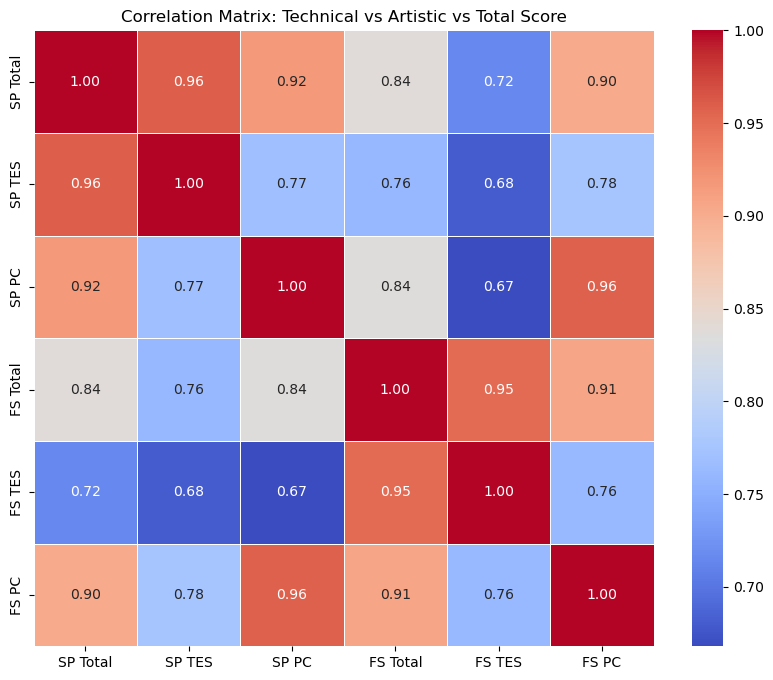

In [29]:
# Select the columns we want to analyze for correlation
cols = ['SP Total', 'SP TES', 'SP PC', 'FS Total', 'FS TES', 'FS PC']
corr_data = df[cols]

# Calculate the correlation matrix
corr_matrix = corr_data.corr()

# Set the figure size
plt.figure(figsize=(10, 8))

# Create a heatmap with annotations to show correlation coefficients
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add title
plt.title('Correlation Matrix: Technical vs Artistic vs Total Score')

# Display the plot
plt.show()

# Key Findings & Conclusions
1.  **Upward trend in scores**: Both short program and free skate total scores show a clear upward trend from 2005 to 2026, reflecting increasing technical difficulty and performance standards in men's singles figure skating.
2.  **Technical scores are the main driver**: In both SP and FS, average TES scores have increased more rapidly than PCS scores, indicating that rising technical difficulty (e.g., quadruple jumps) is the primary factor behind higher total scores.
3.  **Strong correlations**: The correlation heatmap shows very high positive correlations between total scores and their corresponding TES/PCS, with TES showing a slightly stronger relationship, confirming that technical performance is a key predictor of competition success.